# 서울시 CCTV 현황 분석 및 인구 현황 분석

### CCTV 설치현황

In [93]:
import pandas as pd

In [94]:
CCTV_Seoul = pd.read_excel("../Data/CCTV_in_Seoul_2018.xlsx")
CCTV_Seoul.head()

,기관명,소계,2011년 이전,2012년,2013년,2014년,2015년,2016년,2017년,2018년
0,강남구,5221,1944.0,195.0,316.0,430,546,765,577,448
1,강동구,1879,303.0,387.0,134.0,59,144,194,273,385
2,강북구,1265,243.0,88.0,141.0,74,145,254,1,319
3,강서구,1617,219.0,155.0,118.0,230,187,190,264,254
4,관악구,3985,430.0,56.0,419.0,487,609,619,694,671


In [95]:
CCTV_Seoul.tail()

,기관명,소계,2011년 이전,2012년,2013년,2014년,2015년,2016년,2017년,2018년
20,용산구,2063,1279.0,152.0,201.0,107,102,89,60,73
21,은평구,2962,1365.0,83.0,99.0,343,180,296,229,367
22,종로구,1471,8.0,7.0,599.0,132,195,148,281,101
23,중구,1544,25.0,165.0,114.0,80,245,270,317,328
24,중랑구,1068,NaN,NaN,NaN,770,102,121,66,9


In [96]:
CCTV_Seoul.columns

Index(['기관명', '소계', '2011년 이전', '2012년', '2013년', '2014년', '2015년', '2016년',
       '2017년', '2018년'],
      dtype='object')

In [97]:
# CCTV_Seoul의 첫벌째 컬럼 확인
CCTV_Seoul.columns[0]

'기관명'

In [98]:
# 기관명 -> 구별 로 변경
CCTV_Seoul.rename(columns={'기관명':'구별'}, inplace=True)
CCTV_Seoul.head()

,구별,소계,2011년 이전,2012년,2013년,2014년,2015년,2016년,2017년,2018년
0,강남구,5221,1944.0,195.0,316.0,430,546,765,577,448
1,강동구,1879,303.0,387.0,134.0,59,144,194,273,385
2,강북구,1265,243.0,88.0,141.0,74,145,254,1,319
3,강서구,1617,219.0,155.0,118.0,230,187,190,264,254
4,관악구,3985,430.0,56.0,419.0,487,609,619,694,671


In [99]:
# NaN을 확인하고 NaN을 0으로 대체하기
CCTV_Seoul.fillna(0, inplace=True)
CCTV_Seoul.isnull().sum()

구별          0
소계          0
2011년 이전    0
2012년       0
2013년       0
2014년       0
2015년       0
2016년       0
2017년       0
2018년       0
dtype: int64

---
### 인구현황

In [100]:
seoulPop = pd.read_excel("../Data/population_in_Seoul_2020.xlsx", header=3)
seoulPop.head()

,기간,자치구,세대,계,남자,여자,계.1,남자.1,여자.1,계.2,남자.2,여자.2,세대당인구,65세이상고령자
0,2020.1/4,합계,4354006,10013781,4874995,5138786,9733655,4742217,4991438,280126,132778,147348,2.24,1518239
1,2020.1/4,종로구,74151,161984,78271,83713,151217,73704,77513,10767,4567,6200,2.04,28073
2,2020.1/4,중구,63045,136469,66769,69700,126175,61839,64336,10294,4930,5364,2.00,23794
3,2020.1/4,용산구,110895,246165,119961,126204,229579,110667,118912,16586,9294,7292,2.07,39439
4,2020.1/4,성동구,135643,307193,149891,157302,299042,146300,152742,8151,3591,4560,2.20,44728


In [101]:
seoulPop[['자치구','계','계.1','계.2','65세이상고령자']].head()

,자치구,계,계.1,계.2,65세이상고령자
0,합계,10013781,9733655,280126,1518239
1,종로구,161984,151217,10767,28073
2,중구,136469,126175,10294,23794
3,용산구,246165,229579,16586,39439
4,성동구,307193,299042,8151,44728


In [102]:
seoulPop = pd.read_excel("../Data/population_in_Seoul_2020.xlsx",
                        header=3,
                        usecols='B, D, G, J, N', # 엑셀 컬럼
                        names=['구별','인구수','한국인','외국인','고령자']  # 컬럼이름 지정
                        )
seoulPop.head()

,구별,인구수,한국인,외국인,고령자
0,합계,10013781,9733655,280126,1518239
1,종로구,161984,151217,10767,28073
2,중구,136469,126175,10294,23794
3,용산구,246165,229579,16586,39439
4,성동구,307193,299042,8151,44728


In [103]:
# 합계 행을 삭제 ( index 번호로 삭제 )
seoulPop.drop(0, axis=0, inplace=True)



In [104]:
seoulPop.head()

,구별,인구수,한국인,외국인,고령자
1,종로구,161984,151217,10767,28073
2,중구,136469,126175,10294,23794
3,용산구,246165,229579,16586,39439
4,성동구,307193,299042,8151,44728
5,광진구,365990,350417,15573,48989


In [105]:
seoulPop.tail()

,구별,인구수,한국인,외국인,고령자
21,관악구,516662,499374,17288,76664
22,서초구,434801,430568,4233,58332
23,강남구,549898,544804,5094,72602
24,송파구,680883,674095,6788,89539
25,강동구,457042,452646,4396,66401


### CCTV 현황

In [106]:
# CCTV 에서 소계로 오름차순 정렬
CCTV_Seoul.sort_values('소계', inplace=True)
CCTV_Seoul.head()

,구별,소계,2011년 이전,2012년,2013년,2014년,2015년,2016년,2017년,2018년
9,도봉구,858,197.0,66.0,8.0,185,59,155,117,71
24,중랑구,1068,0.0,0.0,0.0,770,102,121,66,9
2,강북구,1265,243.0,88.0,141.0,74,145,254,1,319
22,종로구,1471,8.0,7.0,599.0,132,195,148,281,101
23,중구,1544,25.0,165.0,114.0,80,245,270,317,328


> CCTV 댓수가 적은 지역으로는 도봉구, 중랑구, 강북구, 종로구, 중구 순이다.

In [107]:
# CCTV에서 소계로 내림차순 정렬
CCTV_Seoul.sort_values(by='소계', ascending=False).head()

,구별,소계,2011년 이전,2012년,2013년,2014년,2015년,2016년,2017년,2018년
0,강남구,5221,1944.0,195.0,316.0,430,546,765,577,448
4,관악구,3985,430.0,56.0,419.0,487,609,619,694,671
6,구로구,3227,852.0,219.0,349.0,187,268,326,540,486
16,성북구,3003,779.0,84.0,304.0,241,279,388,285,643
21,은평구,2962,1365.0,83.0,99.0,343,180,296,229,367


> CCTV댓수가 많은 지역으로는 강남구, 관악구, 구로구, 성북구, 은평구 순이다.

In [108]:
#### 최근 3년간 CCTV증가율 구해서 CCTV가 제일 많이 증가한 구를 검색후 정렬

CCTV_Seoul['최근증가율'] =  CCTV_Seoul.loc[:,'2016년':'2018년'].sum(axis=1) \
                 / CCTV_Seoul.loc[:,'2011년 이전':'2015년'].sum(axis=1) * 100

In [109]:
CCTV_Seoul.sort_values('최근증가율', ascending=False, inplace=True)

In [110]:
CCTV_Seoul.head()

,구별,소계,2011년 이전,2012년,2013년,2014년,2015년,2016년,2017년,2018년,최근증가율
23,중구,1544,25.0,165.0,114.0,80,245,270,317,328,145.468998
19,영등포구,2495,132.0,121.0,206.0,217,366,289,371,793,139.443378
15,성동구,2679,665.0,109.0,118.0,101,258,201,933,294,114.148681
7,금천구,1634,27.0,17.0,242.0,101,382,136,199,530,112.483745
5,광진구,1581,470.0,42.0,83.0,87,64,21,468,346,111.930295


> 결과를 보면 최근 3년간의 CCTV가 2015년 이전에 비해 가장 많이 증가한 곳은 중구, 영등포구, 성동구, 금천구, 광진구 순이다.

---
### 인구현황

In [111]:
# 구별 Data의 유효성 확인
len(seoulPop['구별'].unique())

25

In [112]:
seoulPop.head()

,구별,인구수,한국인,외국인,고령자
1,종로구,161984,151217,10767,28073
2,중구,136469,126175,10294,23794
3,용산구,246165,229579,16586,39439
4,성동구,307193,299042,8151,44728
5,광진구,365990,350417,15573,48989


In [113]:
seoulPop['외국인비율'] = seoulPop['외국인'] / seoulPop['인구수'] * 100
seoulPop['고령자비율'] = seoulPop['고령자'] / seoulPop['인구수'] * 100

In [114]:
seoulPop.head()

,구별,인구수,한국인,외국인,고령자,외국인비율,고령자비율
1,종로구,161984,151217,10767,28073,6.646953,17.330724
2,중구,136469,126175,10294,23794,7.543105,17.435462
3,용산구,246165,229579,16586,39439,6.737757,16.021368
4,성동구,307193,299042,8151,44728,2.653381,14.560228
5,광진구,365990,350417,15573,48989,4.255034,13.385338


In [115]:
# 인구수가 제일 많은 지역은 Top5
seoulPop.sort_values(by='인구수', ascending=False).head()


,구별,인구수,한국인,외국인,고령자,외국인비율,고령자비율
24,송파구,680883,674095,6788,89539,0.996941,13.150424
16,강서구,595703,589302,6401,85992,1.074529,14.435381
23,강남구,549898,544804,5094,72602,0.926354,13.202812
11,노원구,535495,531037,4458,82682,0.832501,15.440294
21,관악구,516662,499374,17288,76664,3.346095,14.838328


In [116]:
# 외국인이 제일 많은 지역은 Top5
seoulPop.sort_values(by='외국인', ascending=False).head()

,구별,인구수,한국인,외국인,고령자,외국인비율,고령자비율
19,영등포구,404766,371903,32863,59373,8.119012,14.668475
17,구로구,438308,405837,32471,67432,7.408261,15.384615
18,금천구,251370,232583,18787,38508,7.473843,15.319251
21,관악구,516662,499374,17288,76664,3.346095,14.838328
6,동대문구,362793,346156,16637,60367,4.585811,16.639516


> 외국인 인구가 많은 구로는 영등포구, 구로구, 금천구, 관악구, 동대문구가 있다.

In [117]:
# 외국인 비율이 높은 지역은 Top5
seoulPop.sort_values(by='외국인비율', ascending=False).head()

,구별,인구수,한국인,외국인,고령자,외국인비율,고령자비율
19,영등포구,404766,371903,32863,59373,8.119012,14.668475
2,중구,136469,126175,10294,23794,7.543105,17.435462
18,금천구,251370,232583,18787,38508,7.473843,15.319251
17,구로구,438308,405837,32471,67432,7.408261,15.384615
3,용산구,246165,229579,16586,39439,6.737757,16.021368


In [118]:
# 고령자 정렬
seoulPop.sort_values(by='고령자', ascending=False).head()

,구별,인구수,한국인,외국인,고령자,외국인비율,고령자비율
24,송파구,680883,674095,6788,89539,0.996941,13.150424
16,강서구,595703,589302,6401,85992,1.074529,14.435381
11,노원구,535495,531037,4458,82682,0.832501,15.440294
12,은평구,482509,478019,4490,82245,0.930553,17.045278
21,관악구,516662,499374,17288,76664,3.346095,14.838328


In [119]:
# 고령자 비율 정렬
seoulPop.sort_values(by='고령자비율', ascending=False).head()

,구별,인구수,한국인,외국인,고령자,외국인비율,고령자비율
9,강북구,316750,312985,3765,61660,1.188635,19.466456
10,도봉구,333495,331238,2257,60023,0.676772,17.998171
2,중구,136469,126175,10294,23794,7.543105,17.435462
1,종로구,161984,151217,10767,28073,6.646953,17.330724
12,은평구,482509,478019,4490,82245,0.930553,17.045278


### 3조 분석 결과
> 영등포구가 외국인인구수, 외국인 비율이 가장 높게 나타나는 경향을 보인다.<br>      
> 영등포구, 금천구, 구로구는 외국인 인구수와 외국인비율이 높게 나타나는 경향을 보인다.<br> 
> 은평구를 제외한 나머지 구는 고령자인구와 고령자비율이 비례하지 않는다.<br>    
> 인구수가 많은 상위 다섯개 구 중에 4개의 구가 고령자수가 높게 나타나는 경향을 보인다.(즉 인구수와 고령자수는 비례관계를 보인다.) <br>            
> 고령자 비율은 강북지역이 높다.      <br> 
> 인구수 상위 5개 지역구 중 4군데가 강남지역이다.<br> 

인구수가 제일 많은 지역은 송파구이지만, 영등포구가 제일 외국인이 많다. <br>
그리고 그 근처라고 할 수 있는 구로구, 금천구 등도 굉장히 외국인이 많다. <br>
송파구는 고령자가 제일 많지만 고령자의 비율이 높지 않은 것이 확인된다. <br>
하지만 강북구, 도봉구, 중구, 종로구, 은평구 같은 경우는 <br>
인구수 대비 고령자 비율이 많기 때문에 추후 고령화가 우려된다. <br>

---
# CCTV와 인구현황 합치기

In [120]:
data_result = pd.merge(seoulPop, CCTV_Seoul, on='구별', how='outer')
data_result.head()

,구별,인구수,한국인,외국인,고령자,외국인비율,고령자비율,소계,2011년 이전,2012년,2013년,2014년,2015년,2016년,2017년,2018년,최근증가율
0,종로구,161984,151217,10767,28073,6.646953,17.330724,1471,8.0,7.0,599.0,132,195,148,281,101,56.323061
1,중구,136469,126175,10294,23794,7.543105,17.435462,1544,25.0,165.0,114.0,80,245,270,317,328,145.468998
2,용산구,246165,229579,16586,39439,6.737757,16.021368,2063,1279.0,152.0,201.0,107,102,89,60,73,12.058664
3,성동구,307193,299042,8151,44728,2.653381,14.560228,2679,665.0,109.0,118.0,101,258,201,933,294,114.148681
4,광진구,365990,350417,15573,48989,4.255034,13.385338,1581,470.0,42.0,83.0,87,64,21,468,346,111.930295


In [121]:
delColumn = data_result.columns[8:16]

for i in delColumn:
    del data_result[i]
data_result.head()

,구별,인구수,한국인,외국인,고령자,외국인비율,고령자비율,소계,최근증가율
0,종로구,161984,151217,10767,28073,6.646953,17.330724,1471,56.323061
1,중구,136469,126175,10294,23794,7.543105,17.435462,1544,145.468998
2,용산구,246165,229579,16586,39439,6.737757,16.021368,2063,12.058664
3,성동구,307193,299042,8151,44728,2.653381,14.560228,2679,114.148681
4,광진구,365990,350417,15573,48989,4.255034,13.385338,1581,111.930295


In [122]:
data_result.set_index('구별', inplace=True)


In [123]:
data_result.head()

,인구수,한국인,외국인,고령자,외국인비율,고령자비율,소계,최근증가율
구별,,,,,,,,
종로구,161984,151217,10767,28073,6.646953,17.330724,1471,56.323061
중구,136469,126175,10294,23794,7.543105,17.435462,1544,145.468998
용산구,246165,229579,16586,39439,6.737757,16.021368,2063,12.058664
성동구,307193,299042,8151,44728,2.653381,14.560228,2679,114.148681
광진구,365990,350417,15573,48989,4.255034,13.385338,1581,111.930295


In [124]:
import numpy as np

In [125]:
# 고령자 비율과 소계의 상관계수
np.corrcoef(data_result['고령자비율'], data_result['소계'])

array([[ 1.        , -0.44225083],
       [-0.44225083,  1.        ]])

In [126]:
# 고령자와 소계의 상관계수
np.corrcoef(data_result['고령자'], data_result['소계'])

array([[1.        , 0.28638538],
       [0.28638538, 1.        ]])

In [127]:
# 외국인 비율과 소계의 상관계수
np.corrcoef(data_result['외국인비율'], data_result['소계'])

array([[ 1.        , -0.06215538],
       [-0.06215538,  1.        ]])

In [128]:
# 외국인과 소계의 상관계수
np.corrcoef(data_result['외국인'], data_result['소계'])

array([[1.        , 0.17444235],
       [0.17444235, 1.        ]])

In [129]:
# 인구수와 소계의 상관계수
np.corrcoef(data_result['인구수'], data_result['소계'])

array([[1.        , 0.38064812],
       [0.38064812, 1.        ]])

> 고령자 비율의 상관계수를 보면 역상관이 발생하고 있는 고령자가 아닌 젊은층 비율이 높은 곳에 CCTV가 많이 설치되는 경향을 보이며 <br>
> 주로 인구수와 양의 상관을 보이고 있어 CCTV 댓수는 인구수에 비례하여 증가하는 경향을 보인다.

---
# 시각화

In [130]:
import matplotlib.pyplot as plt

In [203]:
# 한글 폰트 문제 해결 
# matplotlib은 한글 폰트를 지원하지 않음
# os정보
import platform

# font_manager : 폰트 관리 모듈
# rc : 폰트 변경 모듈
from matplotlib import font_manager, rc
# unicode 설정
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Darwin':
    rc('font', family='AppleGothic') # os가 macos
elif platform.system() == 'Windows':
    path = 'c:/Windows/Fonts/malgun.ttf' # os가 windows
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc('font', family=font_name)
else:
    print("Unknown System")

In [132]:
data_result.head()

,인구수,한국인,외국인,고령자,외국인비율,고령자비율,소계,최근증가율
구별,,,,,,,,
종로구,161984,151217,10767,28073,6.646953,17.330724,1471,56.323061
중구,136469,126175,10294,23794,7.543105,17.435462,1544,145.468998
용산구,246165,229579,16586,39439,6.737757,16.021368,2063,12.058664
성동구,307193,299042,8151,44728,2.653381,14.560228,2679,114.148681
광진구,365990,350417,15573,48989,4.255034,13.385338,1581,111.930295


In [133]:
# 파일로 저장(CCTV_result.csv)
data_result.to_csv("../Data/CCTV_result.csv")

In [134]:
plt.style.use('ggplot')

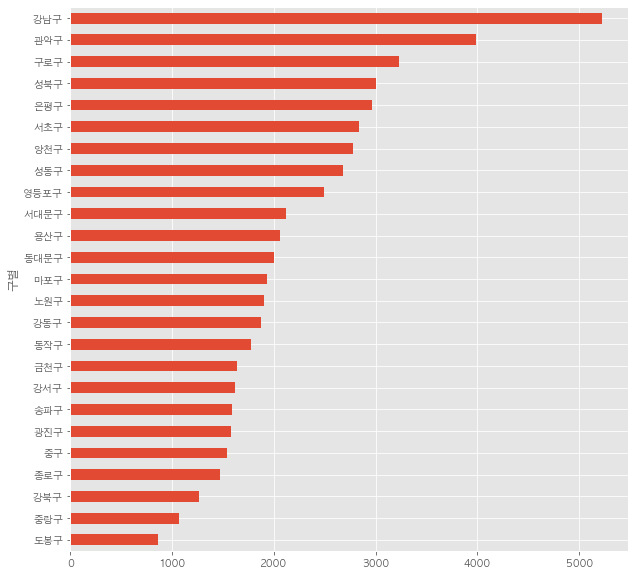

In [135]:
data_result['소계'].sort_values().plot(

    kind = 'barh',
    grid = True,
    figsize = (10,10)
)

plt.show()

### 인구대비 CCTV 비율

In [136]:
data_result['CCTV비율'] = data_result['소계'] / data_result['인구수'] * 100
data_result.head()

,인구수,한국인,외국인,고령자,외국인비율,고령자비율,소계,최근증가율,CCTV비율
구별,,,,,,,,,
종로구,161984,151217,10767,28073,6.646953,17.330724,1471,56.323061,0.908114
중구,136469,126175,10294,23794,7.543105,17.435462,1544,145.468998,1.131392
용산구,246165,229579,16586,39439,6.737757,16.021368,2063,12.058664,0.838056
성동구,307193,299042,8151,44728,2.653381,14.560228,2679,114.148681,0.872090
광진구,365990,350417,15573,48989,4.255034,13.385338,1581,111.930295,0.431979


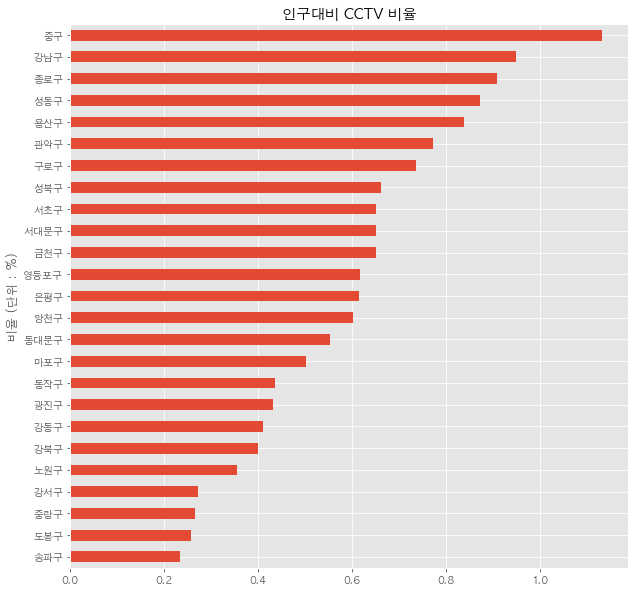

In [145]:
data_result['CCTV비율'].sort_values().plot(
    kind="barh",
    grid = True,
    figsize = (10,10)
)

plt.ylabel('비율 (단위 : %)')
plt.title('인구대비 CCTV 비율')
plt.show()

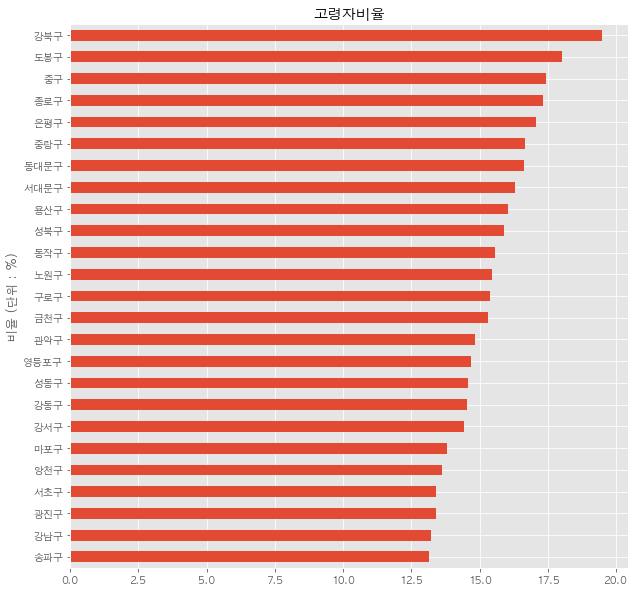

In [150]:
data_result['고령자비율'].sort_values().plot(
    kind="barh",
    grid = True,
    figsize = (10,10)
)

plt.ylabel('비율 (단위 : %)')
plt.title('고령자비율')
plt.show()

> 중구가 CCTV 대수는 가장 적으나 인구대비 CCTV 비율이 가장 높게 나타난다. <br>
> 강남구가 CCTV 대수가 가장 높게 나타나고 비율 또한 2번째로 가장 높게 나타난다. <br>
> 강북구, 도봉구 는 고령자비율이 가장 높지만, CCTV 비율은 밑에서 6번째, 2번째로 낮게 나타난다. <br>
 


In [194]:
import seaborn as sns

In [201]:
sns.set_style('whitegrid')

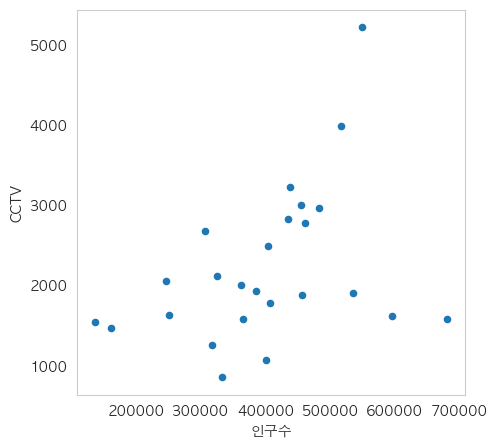

In [204]:
# 산점도를 이용한 시각화 (인구수와 소계)

# plt.figure(figsize=(6,6))
# plt.scatter(data_result['인구수'], data_result['소계'])
# plt.xlabel('인구수')


data_result.plot(
    kind = 'scatter',
    x = '인구수',
    y = '소계',
    figsize = (5,5)
)

plt.ylabel('CCTV')
plt.grid()
plt.show()

In [197]:
# 인구수, 소계에 따른 기준직선(회귀선, 평균선) 만들기
fp1 = np.polyfit(data_result['인구수'], data_result['소계'], 1)
fp1

array([2.88522756e-03, 1.06403852e+03])

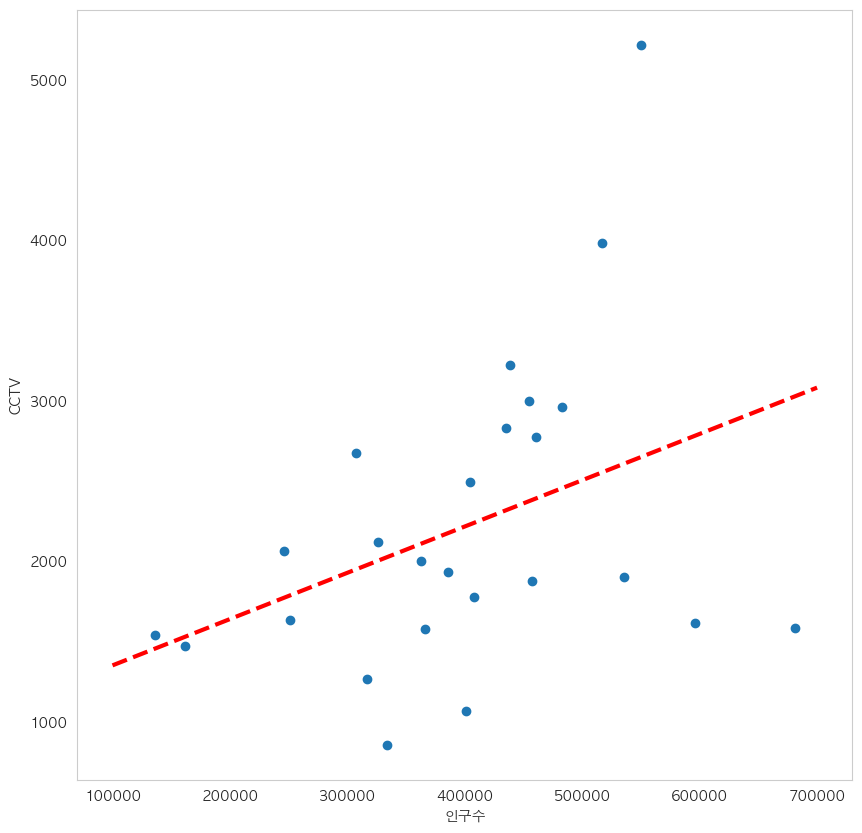

In [207]:
# x축 만들기 : 인구수 표현
fx = np.linspace(100000, 700000)

# y축 데이터 만들기 : CCTV 소계 표현
f1 = np.poly1d(fp1)

plt.figure(figsize=(10,10))
plt.scatter(data_result['인구수'], data_result['소계'])
plt.plot(fx, f1(fx), ls = 'dashed', lw=3, color='r') # 기준 직선(회귀선, 평균선,,)
plt.xlabel('인구수')
plt.ylabel('CCTV')
plt.grid()
plt.show()

> 이 직선은 CCTV 댓수에 기준값이 된다. <br>
> 이 직선을 기준으로 상위에 있는 점은 과하게 설치 된 것이고<br>
> 직선 보다 하위에 있는 점은 인구수에 비해 CCTV가 부족하다는 해석이 됩니다.

In [209]:
# 기준선 구하기
fp1 = np.polyfit(data_result['인구수'], data_result['소계'], 1)

# 기준치 구하기
f1 = np.poly1d(fp1)

# 인구수
fx = np.linspace(100000, 700000)

# 소계에서 기준인구수 차이로 오차값 구하기
data_result['오차'] = np.abs(data_result['소계']- f1(data_result['인구수']))

# 정렬
df_sort = data_result.sort_values(by='오차', ascending=False)
df_sort.head()

,인구수,한국인,외국인,고령자,외국인비율,고령자비율,소계,최근증가율,CCTV비율,오차
구별,,,,,,,,,,
강남구,549898,544804,5094,72602,0.926354,13.202812,5221,52.171379,0.949449,2570.380612
송파구,680883,674095,6788,89539,0.996941,13.150424,1586,62.833676,0.232933,1442.540920
관악구,516662,499374,17288,76664,3.346095,14.838328,3985,99.150425,0.771297,1430.274035
도봉구,333495,331238,2257,60023,0.676772,17.998171,858,66.601942,0.257275,1168.247488
강서구,595703,589302,6401,85992,1.074529,14.435381,1617,77.887789,0.271444,1165.777237


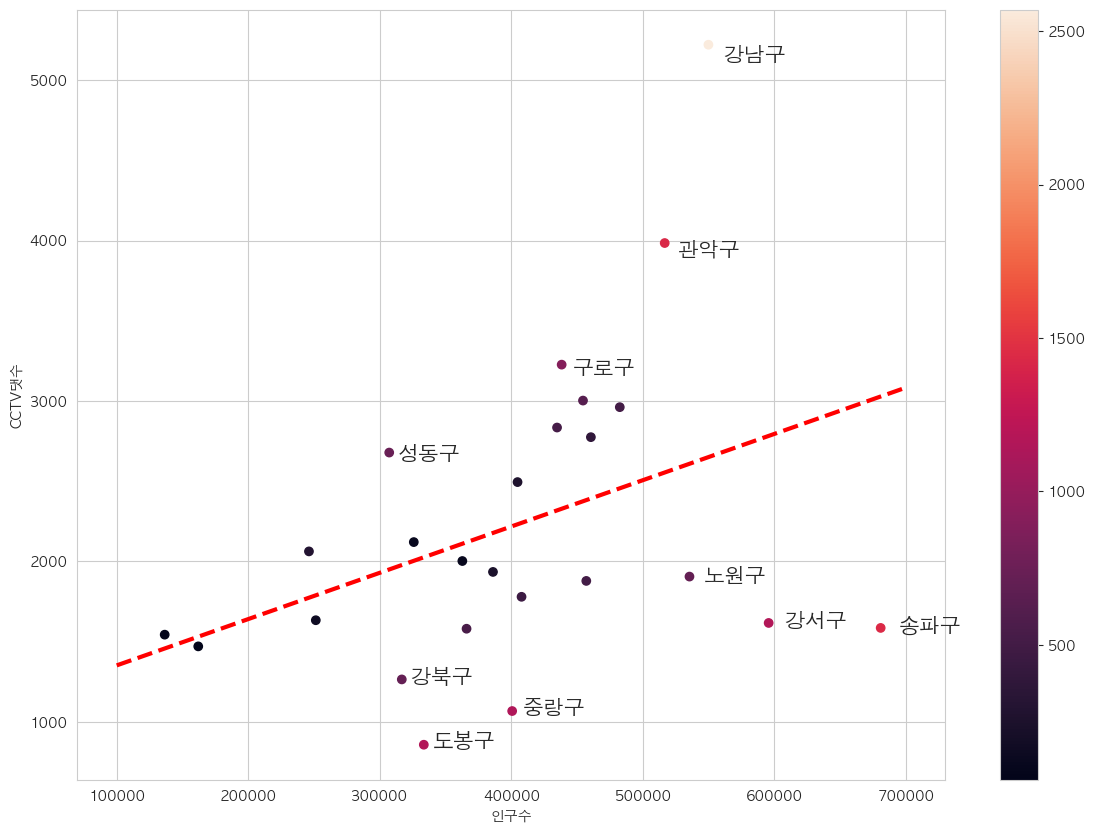

In [218]:
# 그래프에 텍스트와 Color
plt.figure(figsize=(14,10))
plt.scatter(data_result['인구수'], data_result['소계'], c=data_result['오차'])
plt.plot(fx, f1(fx), ls = 'dashed', lw=3, color='r')

# 오차가 가장 큰 10개구에 텍스트 붙이기
for n in range(10):
    plt.text(df_sort['인구수'][n]*1.02, df_sort['소계'][n]*0.98, df_sort.index[n], fontsize=15)

plt.xlabel('인구수')
plt.ylabel('CCTV댓수')
plt.colorbar()
plt.title('')
plt.show()